In [27]:
import pandas as pd
import glob,os

#############################################################################
######### CHANGE INPUT FOLDER HERE ##########################################
#############################################################################
directory_path = "C:/Research-Paper/PAPER-WORK-2024/Outputs/"


# Define the path pattern to get all files ending with 'Equivalent-Query-Check.xlsx'
# example : Spider-Data-1-Equivalent-Query-Check
pattern = '**/*Equivalent-Query-Check.xlsx'

# Use glob to get all files matching the pattern (including subdirectories)
files = glob.glob(directory_path + pattern, recursive=True)

In [40]:
import pandas as pd
import re

#############################################################################
######### CHANGE INPUT FOLDER FILE HERE #####################################
#############################################################################
file_path = r"C:\Research-Paper\PAPER-WORK-2024\Outputs\Spider-Data-1-Equivalent-Query-Check.xlsx"
# Read the excel file
df = pd.read_excel(file_path, engine='openpyxl')
df.head()

,db_id,spider_query,question,text2sql_query,parsed_spider_query,parsed_text2sql_query,normalised_spider_query,normalised_text2sql_query,similarity_score,spider_query_tables,...,hallucinations_in_table_selection,spider_query_columns,text2sql_query_columns,columns_similarity,hallucinations_in_column_selection,spider_query_operations,text2sql_query_operations,operations_similarity,hallucinations_in_operations_selection,hallucinations_in_query
0,farm,SELECT count(*) FROM farm,How many farms are there?,"SELECT COUNT(*) FROM ""farm"" f;","{'tables': ['farm'], 'columns': [], 'operation...","{'tables': ['farm'], 'columns': [], 'operation...",select count(*) from farm,select count(*) from farm farm;,"{'columns_similarity': 1, 'tables_similarity':...",['farm'],...,False,[],[],1.0,False,SortedDict({}),SortedDict({}),1.0,False,False
1,farm,SELECT count(*) FROM farm,Count the number of farms.,SELECT COUNT(*) FROM farm;,"{'tables': ['farm'], 'columns': [], 'operation...","{'tables': ['farm'], 'columns': [], 'operation...",select count(*) from farm,select count(*) from farm;,"{'columns_similarity': 1, 'tables_similarity':...",['farm'],...,False,[],[],1.0,False,SortedDict({}),SortedDict({}),1.0,False,False
2,farm,SELECT Total_Horses FROM farm ORDER BY Total_H...,List the total number of horses on farms in as...,"SELECT f.""Farm_ID"", f.""Total_Horses"" FROM ""far...","{'tables': ['farm'], 'columns': ['total_horses...","{'tables': ['farm'], 'columns': ['farm.farm_id...",select total_horses from farm farm total_horse...,"select farm.farm_id, farm.total_horses from fa...","{'columns_similarity': 0.0, 'tables_similarity...",['farm'],...,False,['total_horses'],"['farm.farm_id', 'farm.total_horses']",0.0,True,"SortedDict({'order_by': ['total_horses'], 'sel...","SortedDict({'order_by': ['farm.total_horses'],...",1.0,False,True
3,farm,SELECT Total_Horses FROM farm ORDER BY Total_H...,"What is the total horses record for each farm,...","SELECT f.""Farm_ID"", f.""Total_Horses"" FROM ""far...","{'tables': ['farm'], 'columns': ['total_horses...","{'tables': ['farm'], 'columns': ['farm.farm_id...",select total_horses from farm farm total_horse...,"select farm.farm_id, farm.total_horses from fa...","{'columns_similarity': 0.0, 'tables_similarity...",['farm'],...,False,['total_horses'],"['farm.farm_id', 'farm.total_horses']",0.0,True,"SortedDict({'order_by': ['total_horses'], 'sel...","SortedDict({'order_by': ['farm.total_horses'],...",1.0,False,True
4,farm,SELECT Hosts FROM farm_competition WHERE Theme...,What are the hosts of competitions whose theme...,SELECT DISTINCT fc.Hosts FROM farm_competition...,"{'tables': ['farm_competition'], 'columns': ['...","{'tables': ['farm_competition'], 'columns': ['...",select hosts from farm_competition farm_compet...,select distinct farm_competition.hosts from fa...,"{'columns_similarity': 0.0, 'tables_similarity...",['farm_competition'],...,False,"['hosts', 'theme']","['farm_competition.hosts', 'farm_competition.t...",0.0,True,"SortedDict({'select': ['hosts'], 'where': ['th...",SortedDict({'select': ['farm_competition.hosts...,1.0,False,True


In [41]:
percentage_true = (df['hallucinations_in_table_selection'].sum() / len(df['hallucinations_in_table_selection'])) * 100
print(f"Percentage of hallucinations_in_table_selection value: {percentage_true:.2f}%")

Percentage of hallucinations_in_table_selection value: 6.26%


In [42]:
percentage_true = (df['hallucinations_in_column_selection'].sum() / len(df['hallucinations_in_column_selection'])) * 100
print(f"Percentage of hallucinations_in_column_selection value: {percentage_true:.2f}%")

Percentage of hallucinations_in_column_selection value: 75.94%


In [43]:
percentage_true = (df['hallucinations_in_operations_selection'].sum() / len(df['hallucinations_in_operations_selection'])) * 100
print(f"Percentage of hallucinations_in_operations_selection value: {percentage_true:.2f}%")

Percentage of hallucinations_in_operations_selection value: 8.62%


In [44]:
percentage_true = (df['hallucinations_in_query'].sum() / len(df['hallucinations_in_query'])) * 100
print(f"Percentage of hallucinations_in_query value: {percentage_true:.2f}%")

Percentage of hallucinations_in_query value: 77.61%


In [45]:
hallucinations_in_table_selection_list = []
hallucinations_in_column_selection_list = []
hallucinations_in_operations_selection_list = []
hallucinations_in_query_list = []

for i in range(1,8):
    file_path = r"C:\Research-Paper\PAPER-WORK-2024\Outputs\Spider-Data-"+str(i)+"-Equivalent-Query-Check.xlsx"
    # Read the excel file
    df = pd.read_excel(file_path, engine='openpyxl')
    print("#"*100)
    print("Spider-Data-"+str(i)+"-Equivalent-Query-Check.xlsx")
    percentage_true = (df['hallucinations_in_table_selection'].sum() / len(df['hallucinations_in_table_selection'])) * 100
    print(f"Percentage of hallucinations_in_table_selection value: {percentage_true:.2f}%")
    hallucinations_in_table_selection_list.append(percentage_true)
    
    percentage_true = (df['hallucinations_in_column_selection'].sum() / len(df['hallucinations_in_column_selection'])) * 100
    print(f"Percentage of hallucinations_in_column_selection value: {percentage_true:.2f}%")
    hallucinations_in_column_selection_list.append(percentage_true)
    
    percentage_true = (df['hallucinations_in_operations_selection'].sum() / len(df['hallucinations_in_operations_selection'])) * 100
    print(f"Percentage of hallucinations_in_operations_selection value: {percentage_true:.2f}%")
    hallucinations_in_operations_selection_list.append(percentage_true)
    
    percentage_true = (df['hallucinations_in_query'].sum() / len(df['hallucinations_in_query'])) * 100
    print(f"Percentage of hallucinations_in_query value: {percentage_true:.2f}%")
    hallucinations_in_query_list.append(percentage_true)
    print("#"*100)

####################################################################################################
Spider-Data-1-Equivalent-Query-Check.xlsx
Percentage of hallucinations_in_table_selection value: 6.26%
Percentage of hallucinations_in_column_selection value: 75.94%
Percentage of hallucinations_in_operations_selection value: 8.62%
Percentage of hallucinations_in_query value: 77.61%
####################################################################################################
####################################################################################################
Spider-Data-2-Equivalent-Query-Check.xlsx
Percentage of hallucinations_in_table_selection value: 6.82%
Percentage of hallucinations_in_column_selection value: 77.19%
Percentage of hallucinations_in_operations_selection value: 8.34%
Percentage of hallucinations_in_query value: 78.72%
####################################################################################################
############################

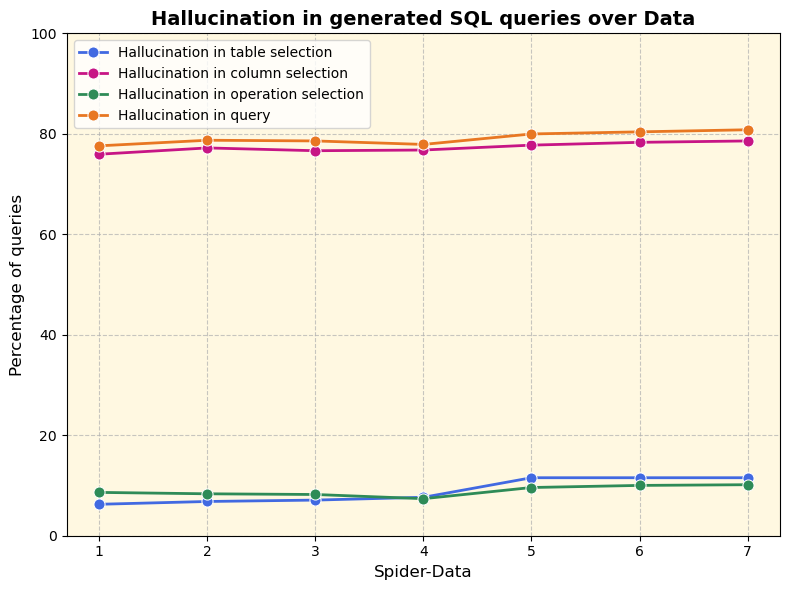

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for Seaborn
df = pd.DataFrame({
    'Index': [1, 2, 3, 4, 5, 6, 7],
    'Hallucination in table selection': hallucinations_in_table_selection_list,
    'Hallucination in column selection': hallucinations_in_column_selection_list,
    'Hallucination in operation selection': hallucinations_in_operations_selection_list,
    'Hallucination in query': hallucinations_in_query_list
})

# Plot the line chart
plt.figure(figsize=(8, 6))  # Set figure size for better readability


# Plot each dataset with its corresponding color
sns.lineplot(data=df, x='Index', y='Hallucination in table selection', marker='o', color='royalblue', linewidth=2, markersize=8, label='Hallucination in table selection')
sns.lineplot(data=df, x='Index', y='Hallucination in column selection', marker='o', color='#C71585', linewidth=2, markersize=8, label='Hallucination in column selection')
sns.lineplot(data=df, x='Index', y='Hallucination in operation selection', marker='o', color='#2E8B57', linewidth=2, markersize=8, label='Hallucination in operation selection')
sns.lineplot(data=df, x='Index', y='Hallucination in query', marker='o', color='#E87722', linewidth=2, markersize=8, label='Hallucination in query')

# Change background color of the plot area (inside the plot)
plt.gca().set_facecolor('#FFF8E1')  # Lighter and brighter cream color


# Enhance graph appearance
plt.title('Hallucination in generated SQL queries over Data', fontsize=14, fontweight='bold')
plt.xlabel('Spider-Data', fontsize=12)
plt.ylabel('Percentage of queries', fontsize=12)
plt.ylim(0, 100)  # Set y-axis scale from 0 to 100
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines with light dashed lines for better readability

# Add legend
plt.legend(fontsize=10, loc='upper left')

# Show the plot
plt.tight_layout()

# Save the plot to a specific location
save_path = 'C:\Research-Paper\PAPER-WORK-2024\Outputs\SQL-Similarity-Score-Analysis\plot-hallucination.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)  # Saves the plot with high resolution

plt.show()